# Estudio tabular: aprender rutas y gestionar riesgo

<a href="https://colab.research.google.com/github/NaoKB/AyalaFilardi-RL/blob/main/Entornos_Complejos/02_estudio_riesgo_tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

RiverCourier plantea una decision con estructura temporal. El vado acorta el
camino, pero su peligro depende de la marea. El puente es seguro y mas largo, y
esperar permite cambiar la fase sin desplazarse.

In [3]:
from pathlib import Path
import subprocess
import sys

candidates = [
    Path.cwd(),
    Path.cwd() / "Entornos_Complejos",
    Path("/content/EML/Entornos_Complejos"),
]
ROOT = next((path.resolve() for path in candidates if (path / "src").is_dir()), None)
if ROOT is None:
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/NaoKB/EML.git", "/content/EML"],
        check=True,
    )
    ROOT = Path("/content/EML/Entornos_Complejos")
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
print(f"Proyecto: {ROOT}")

from src.artifacts import result_path

def result(name):
    return result_path(RESULTS, name)

Proyecto: C:\Users\Joaquín\Desktop\EML\Entornos_Complejos


## Protocolo

- Monte Carlo on-policy first-visit y Monte Carlo off-policy con importancia
  ponderada.
- SARSA y Q-Learning.
- 2600 episodios de entrenamiento y 5 semillas.
- 300 episodios de evaluacion por semilla, sin exploracion.
- Evaluacion nominal y con un aumento del 35% en el riesgo del vado.

In [4]:
import pandas as pd

summary = pd.read_csv(result("tabular_summary.csv"))
table = summary.copy()
table["success_rate"] = (100 * table["success_rate"]).round(1)
table["risk_rate"] = (100 * table["risk_rate"]).round(1)
table[["mean_return", "mean_length"]] = table[["mean_return", "mean_length"]].round(2)
table.rename(columns={"success_rate": "exito_%", "risk_rate": "riesgo_%"}).sort_values(
    ["condition", "mean_return"], ascending=[True, False]
)

Faltan resultados tabulares base; se regenerara el estudio RiverCourier.


,study,agent,condition,mean_return,mean_length,exito_%,riesgo_%
0,tabular,MC off-policy,crecida +35%,12.27,13.54,100.0,0.0
6,tabular,SARSA,crecida +35%,12.23,13.79,100.0,0.0
2,tabular,MC on-policy,crecida +35%,11.72,16.31,99.8,2.3
4,tabular,Q-Learning,crecida +35%,11.16,18.64,98.0,0.2
1,tabular,MC off-policy,marea nominal,12.27,13.54,100.0,0.0
7,tabular,SARSA,marea nominal,12.23,13.79,100.0,0.0
3,tabular,MC on-policy,marea nominal,11.76,16.17,99.8,1.9
5,tabular,Q-Learning,marea nominal,11.16,18.64,98.0,0.2


## Huella completa del aprendizaje

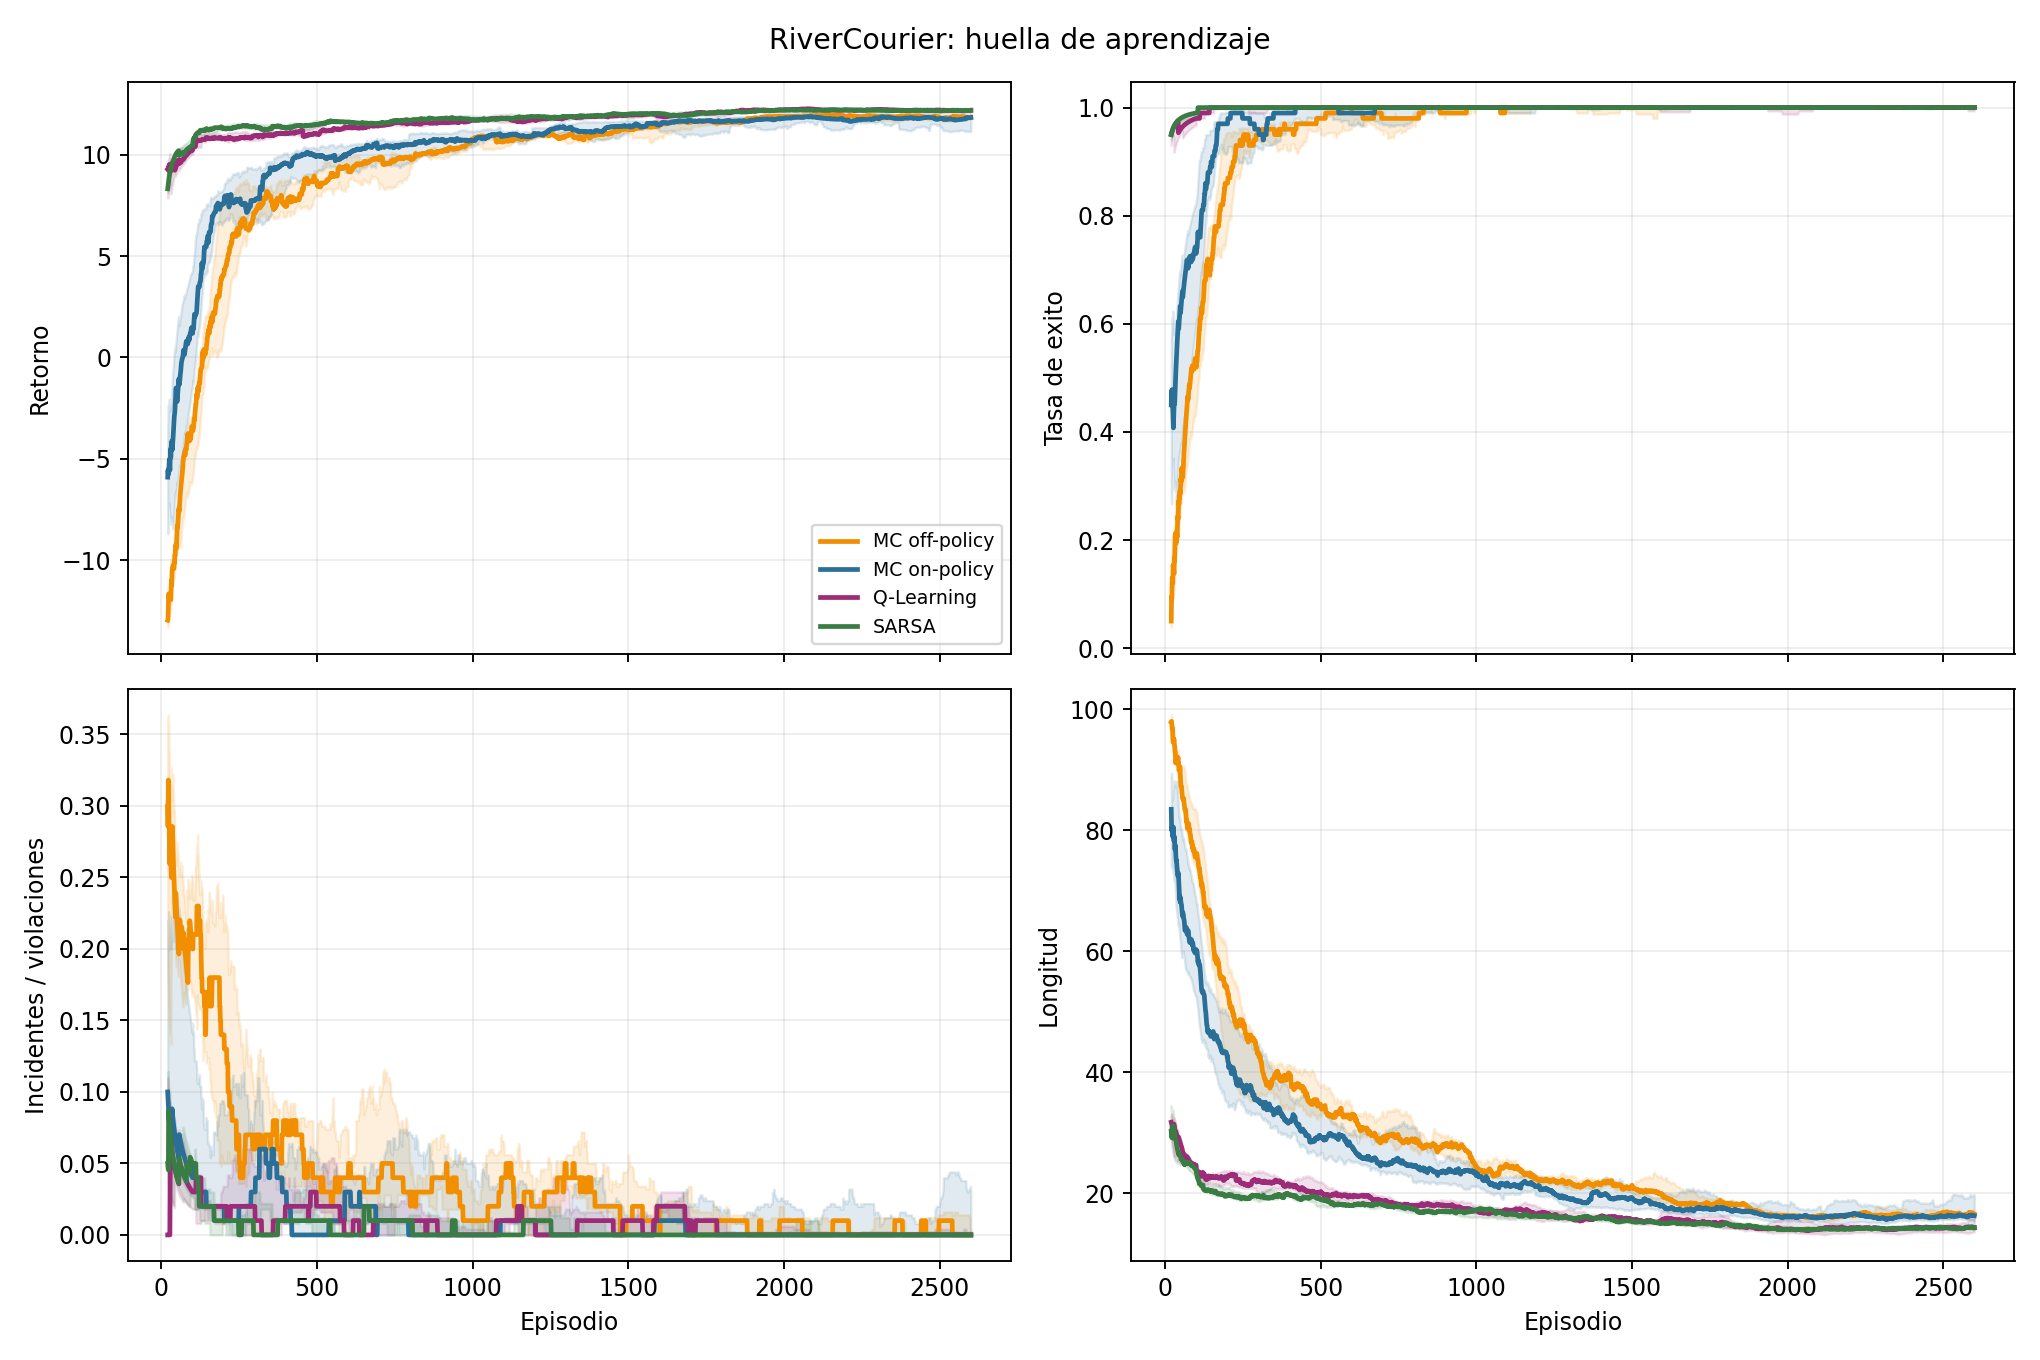

In [5]:
from IPython.display import Image, display

def show_result(name):
    display(Image(filename=str(result(name))))

show_result("tabular_learning_fingerprint.png")

Las cuatro curvas cuentan historias distintas. SARSA y
Q-Learning mejoran pronto; los metodos Monte Carlo necesitan episodios completos y
progresan mas despacio. El descenso de longitud es valioso porque ocurre a la vez
que sube el exito y desaparecen los incidentes. La banda entre semillas tambien
advierte que Q-Learning no termina con la misma politica en todas ellas.

## Robustez y forma de las politicas

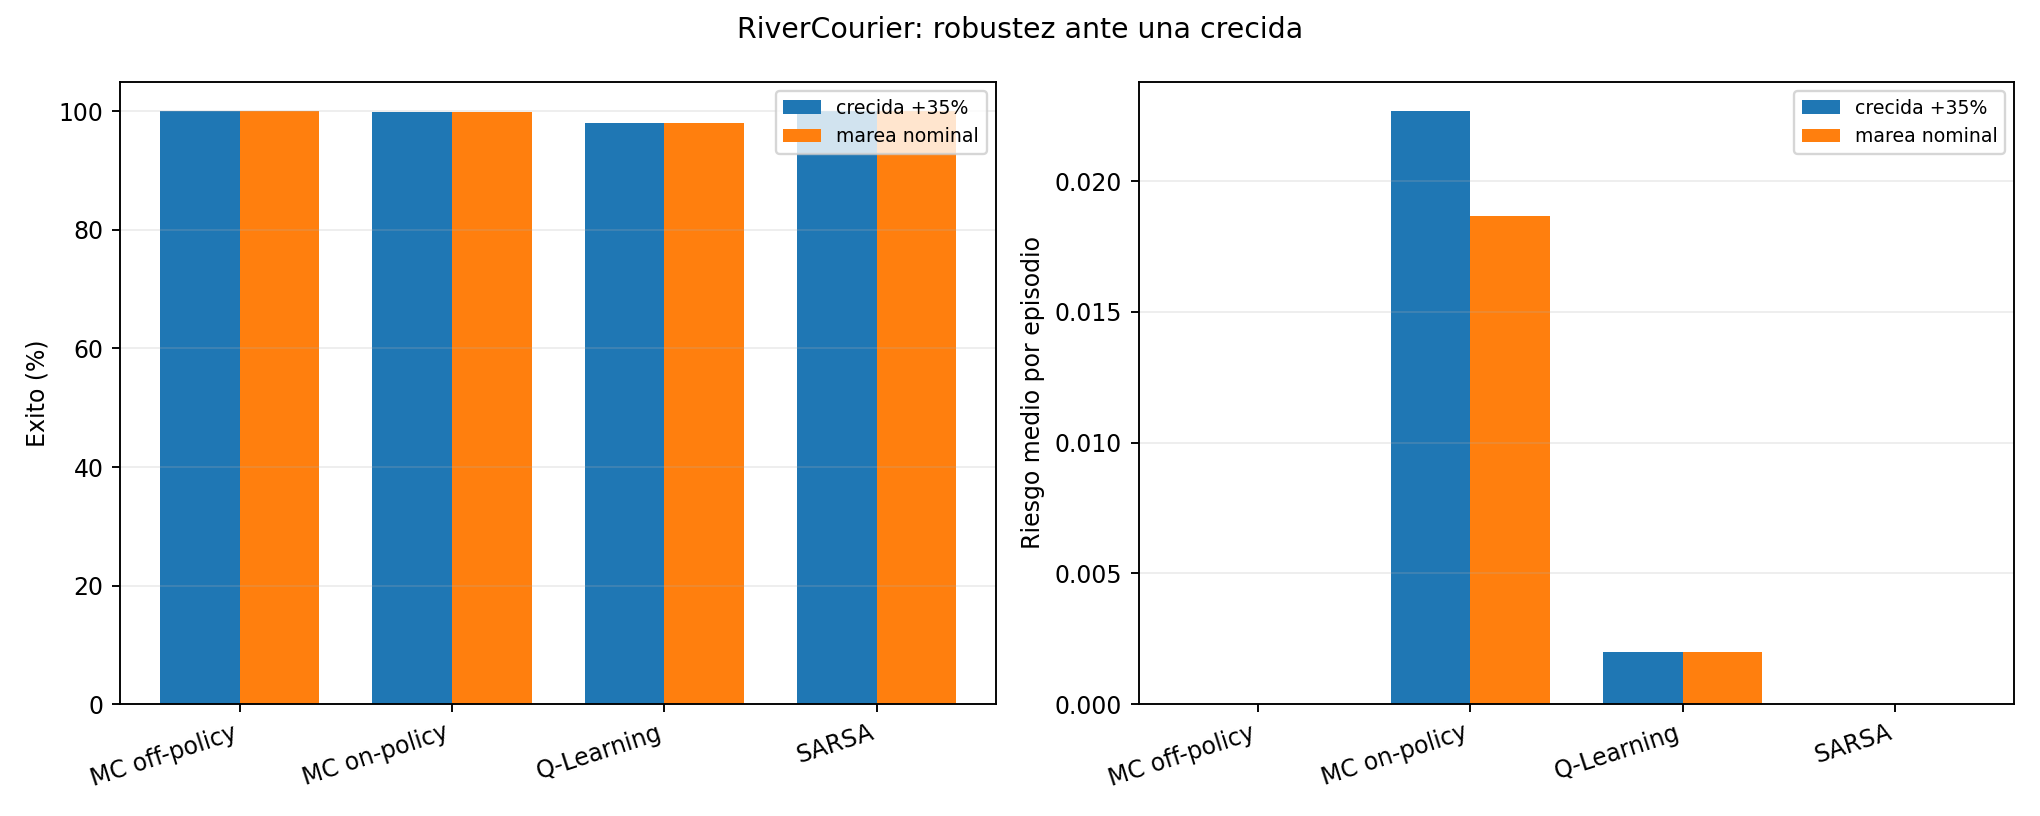

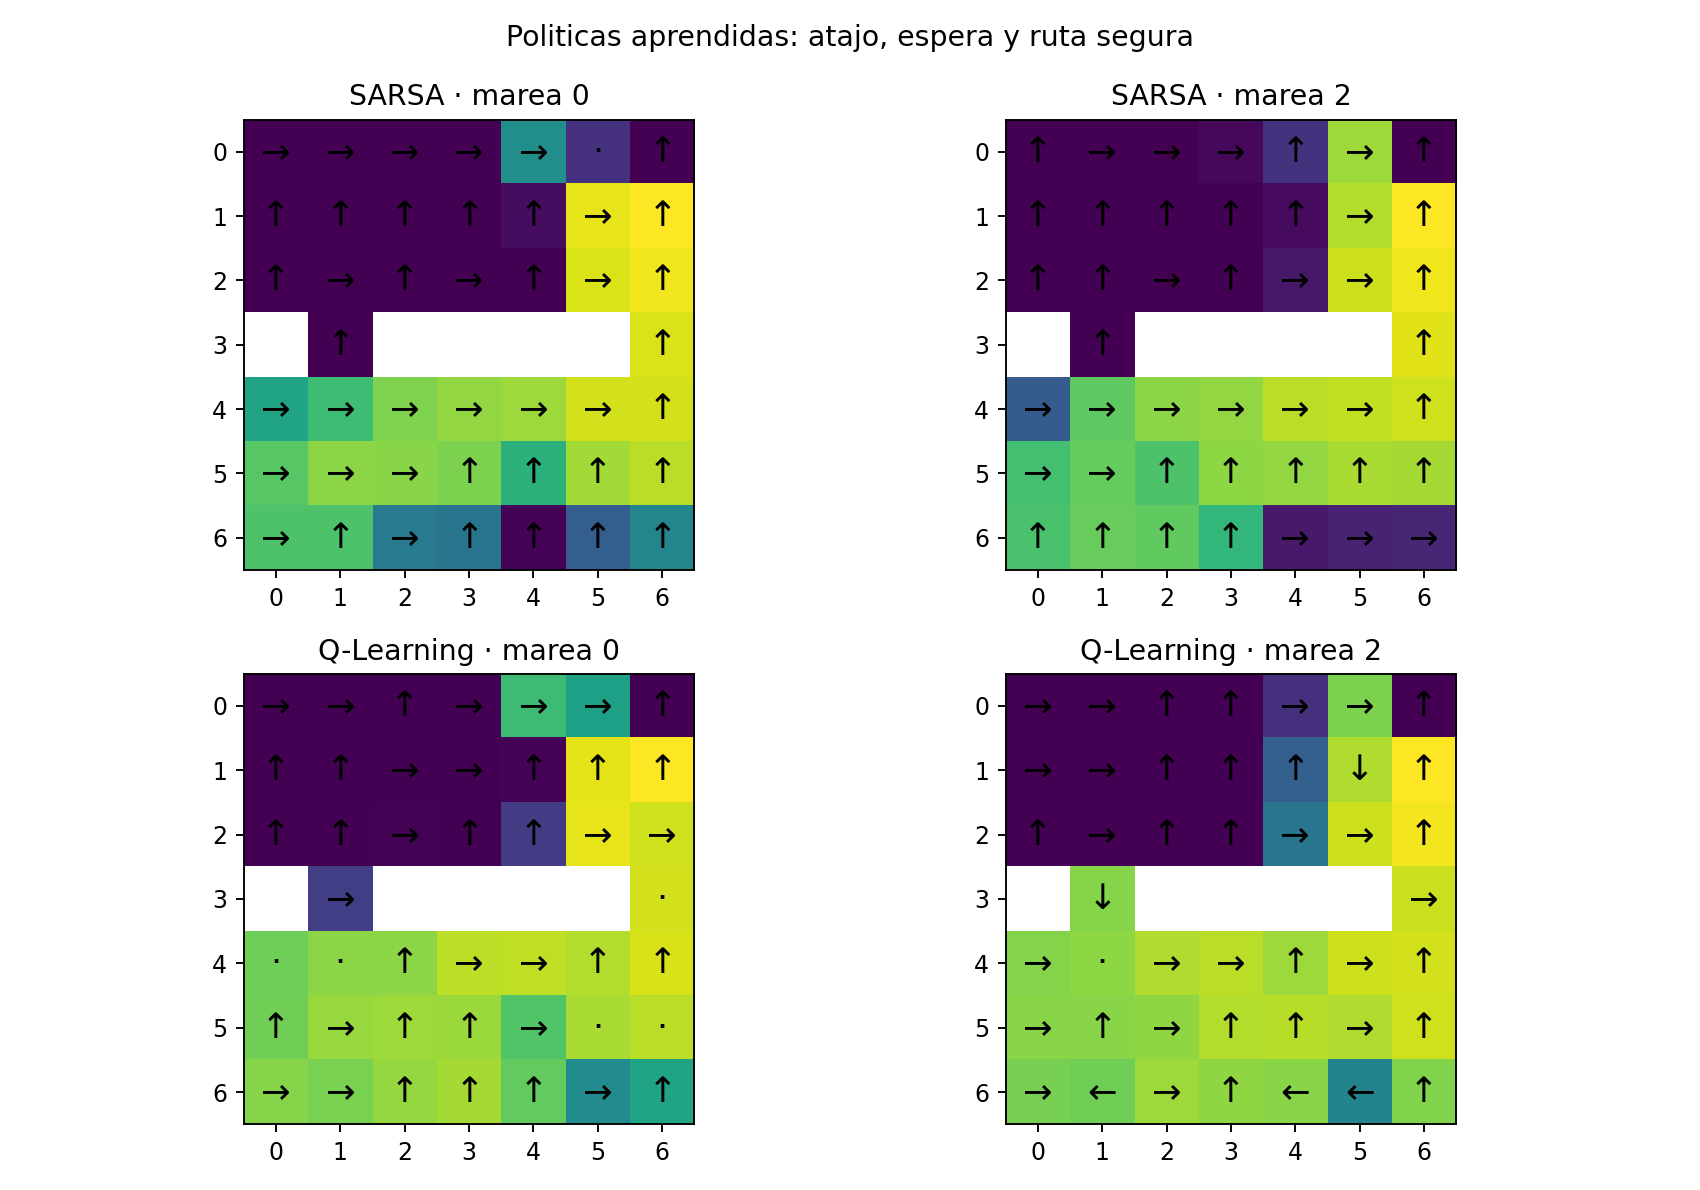

In [6]:
from IPython.display import Image, display

def show_result(name):
    display(Image(filename=str(result(name))))

show_result("tabular_robustness.png")
show_result("river_policy_maps.png")

SARSA y Monte Carlo off-policy alcanzan 100% de exito y riesgo
nulo en ambas condiciones. La crecida apenas cambia sus resultados porque han
aprendido a evitar el vado. Monte Carlo on-policy conserva una pequena exposicion
al riesgo. Los mapas ayudan a inspeccionar la estrategia, aunque las flechas de
estados poco visitados no deben interpretarse como evidencia independiente.

## Variabilidad entre semillas

In [7]:
by_seed = pd.read_csv(result("tabular_evaluation_by_seed.csv"))
by_seed.groupby(["agent", "condition"]).agg(
    exito_minimo=("success_rate", "min"),
    exito_maximo=("success_rate", "max"),
    longitud_media=("mean_length", "mean"),
    longitud_sd=("mean_length", "std"),
).round(3)

exito_minimo  exito_maximo  longitud_media  \
agent         condition                                                   
MC off-policy crecida +35%           1.00           1.0          13.542   
              marea nominal          1.00           1.0          13.542   
MC on-policy  crecida +35%           0.99           1.0          16.307   
              marea nominal          0.99           1.0          16.170   
Q-Learning    crecida +35%           0.90           1.0          18.641   
              marea nominal          0.90           1.0          18.641   
SARSA         crecida +35%           1.00           1.0          13.793   
              marea nominal          1.00           1.0          13.793   

                             longitud_sd  
agent         condition                   
MC off-policy crecida +35%         0.174  
              marea nominal        0.174  
MC on-policy  crecida +35%         2.972  
              marea nominal        2.854  
Q-Learning    crecida +35%        11.151  
              marea nominal       11.151  
SARSA         crecida +35%         0.446  
              marea nominal        0.446

La media final de Q-Learning oculta una semilla claramente peor.
Por ello no se concluye que un algoritmo sea superior solo por una curva
representativa o por una diferencia pequena de retorno.